In [1]:
import os
os.chdir("..")
os.chdir("..")

In [2]:
import minari
import torch
from minari import DataCollector
from torch.utils.data import DataLoader
from gymnasium import spaces

# from ducks.logging.base_logger import logger
from ducks.utils.datat_utils import collate_fn

seed = 42
device = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(seed)
torch.device(device)

device(type='cuda')

In [3]:
### load dataset
minari_dataset = minari.load_dataset("mujoco/hopper/simple-v0")
dataloader = DataLoader(
    minari_dataset, 
    batch_size=32, 
    shuffle=True, 
    collate_fn=collate_fn,
    num_workers=1
)

env = minari_dataset.recover_environment()
observation_space = env.observation_space
action_space = env.action_space
assert isinstance(observation_space, spaces.Box)
assert isinstance(action_space, spaces.Box)

sample_from_batch = next(iter(dataloader))

/home/azm0269@auburn.edu/ducks/newgym/lib/python3.10/site-packages/minari/dataset/minari_dataset.py:204: UserWarning: Installed mujoco version 3.3.7 does not meet the requirement ==3.2.3.
We recommend to install the required version with `pip install "mujoco==3.2.3"`
  warnings.warn(


### Visualize Data

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['figure.figsize'] = [3, 3]
plt.figure(figsize=(4,4))

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

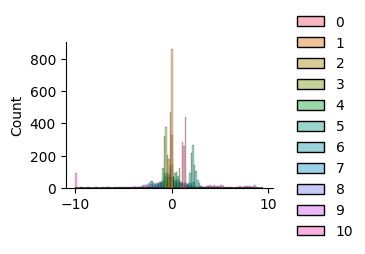

In [19]:
def plot_dist_from_sample(sample):
    sns.displot(sample.cpu().numpy(), kind="hist", height=2, aspect=1.5)
    plt.show()
    
sample = sample_from_batch['observations'][0]
plot_dist_from_sample(sample)
# sample_rewards.shape

### Forward Pass

In [14]:
import torch.nn.functional as F

def linear_beta_schedule(timesteps, start=0.0002, end=0.02):
    return torch.linspace(start, end, timesteps)

def get_index_from_list(vals, t, x_shape):
    batch_size = t.shape[0]
    out = vals.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,)*(len(x_shape)-1))).to(t.device)

def forward_diffusion_sample(x_0, t, device="cuda"):
    noise=torch.randn_like(x_0)
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod, t, x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x_0.shape
    )
    return sqrt_alphas_cumprod_t.to(device)*x_0.to(device)\
        + sqrt_one_minus_alphas_cumprod_t.to(device)*noise.to(device), noise.to(device)
        
## define beta schedule
T = 300 #time steps
betas = linear_beta_schedule(timesteps=T)

# pre-compute terms for closed form solution
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1,0), value=1.0)
sqrt_recip_alphas = torch.sqrt(1.0/alphas) #reciprocal alphas
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod) #this is used up in the forward_diffusion_sample function
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

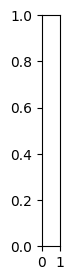

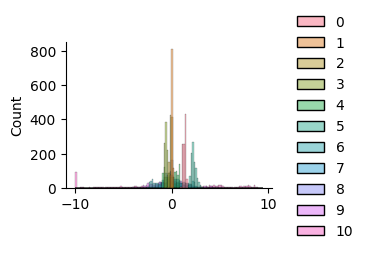

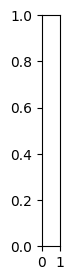

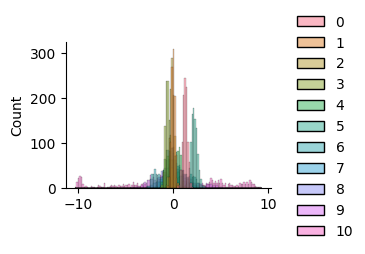

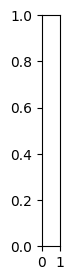

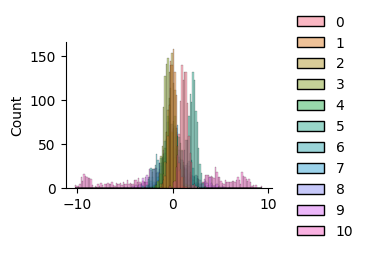

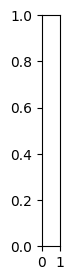

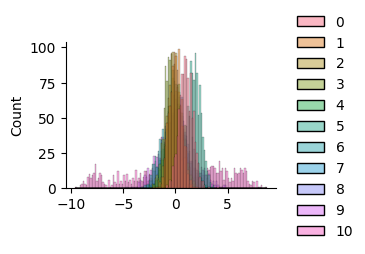

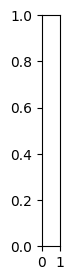

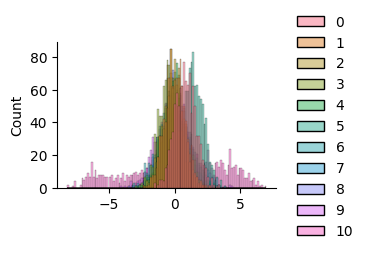

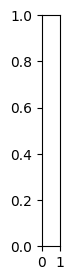

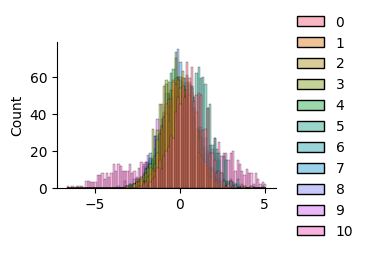

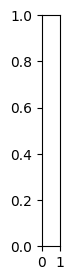

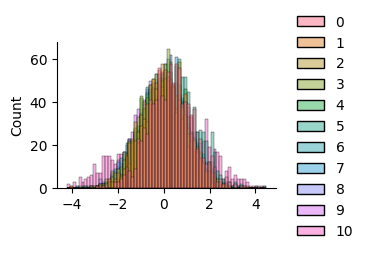

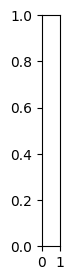

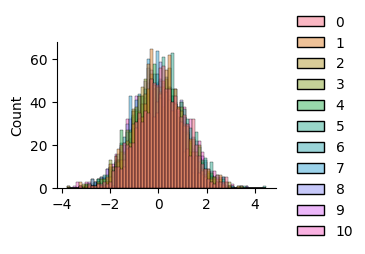

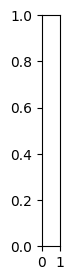

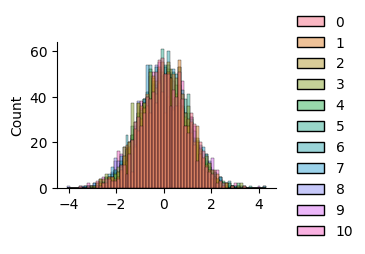

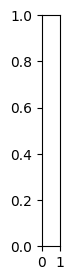

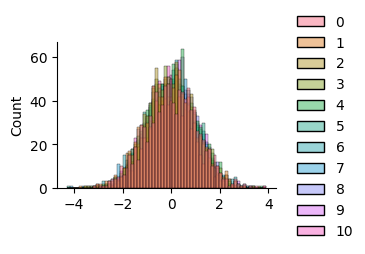

In [20]:
# plt.axis('off')
# sample
num_images = 10
stepsize = int(T/num_images)

for idx in range(0, T, stepsize):
    t = torch.Tensor([idx]).type(torch.int64)
    plt.subplot(1, num_images+1, int(idx/stepsize)+1)
    sample, noise = forward_diffusion_sample(sample, t)
    plot_dist_from_sample(sample)

- every episode interaction yields new information for the agent
- the new information comes in the form of observations and rewards
- as the agent interacts and learns from the environment the rewards go up
- this way the agent learns which observations/states are high reward yielding states
- if the agent is trained from episodic data then a learning agents rewards reflect an upward trajectory
- if epsisodic data is temporally (time) sliced and a diffusion model is trained for each slice then the diffusion model trained on a given slice would
show the environment's state and reward dynamics for the given slice.
- idea: for each time slice train a separate diffusion model -> interpolate the current diffusion model with parameters from the previously trained diffusion model -> generate a batch from this diffusion model -> train the agent on this sample (idea here is that the previous diffusion model contains information which is still relevant for the agent - continual learning?)
- repeat the step above until satisfied.